In [1]:
import polars as pl
features_train_data = pl.read_parquet(r"C:\Users\elmaz\AIProject\NASA_Project\data\processed_data\features_train_data.parquet")


In [2]:
import statsmodels.api as sm
import pandas as pd
import matplotlib as plt
from scipy import signal

In [3]:
features_train_data = features_train_data.to_pandas()

In [4]:
features_train_data.head(10)

,bearing_id,step,mean_ax,rms_ax,std_ax,skew_ax,kurtosis_ax,peak_ax,p2p_ax,crest_ax,...,mean_mag,rms_mag,std_mag,skew_mag,kurtosis_mag,peak_mag,p2p_mag,crest_mag,shape_mag,impulse_mag
0,bearing_1,1,-0.000191,0.538710,0.538815,-0.276842,0.409498,1.767,4.097,3.280058,...,0.588529,0.683523,0.347684,1.017754,1.377136,2.475439,2.462400,3.621589,1.161408,4.206144
1,bearing_1,2,0.003091,0.505577,0.505666,-0.081524,0.196925,1.982,3.797,3.920272,...,0.577723,0.666278,0.331973,0.978966,1.317366,2.308195,2.300385,3.464310,1.153284,3.995333
2,bearing_1,3,-0.007987,0.542441,0.542488,0.091990,0.036907,1.830,3.598,3.373639,...,0.614712,0.706075,0.347445,0.830954,0.684487,2.203390,2.194335,3.120617,1.148627,3.584426
3,bearing_1,4,0.022698,0.515008,0.514608,-0.020372,0.089857,1.600,3.486,3.106749,...,0.609864,0.699846,0.343360,0.839109,0.694571,2.132642,2.126317,3.047303,1.147544,3.496915
4,bearing_1,5,0.002741,0.485601,0.485689,0.014214,-0.040428,1.536,3.241,3.163088,...,0.583227,0.667113,0.323924,0.803853,0.565678,1.994242,1.979109,2.989363,1.143830,3.419325
5,bearing_1,6,0.004711,0.498163,0.498238,-0.031137,-0.267461,1.885,3.581,3.783902,...,0.602789,0.683590,0.322463,0.713622,0.520501,2.071913,2.066913,3.030929,1.134046,3.437213
6,bearing_1,7,-0.008712,0.539167,0.539202,0.014979,-0.116159,1.679,3.781,3.114064,...,0.632636,0.721425,0.346802,0.750038,0.509010,2.329468,2.320924,3.228982,1.140347,3.682159
7,bearing_1,8,-0.007681,0.412902,0.412911,0.073971,0.358507,1.862,3.341,4.509543,...,0.508643,0.581840,0.282581,0.839077,1.052054,2.041064,2.035678,3.507944,1.143907,4.012762
8,bearing_1,9,-0.002699,0.356064,0.356124,-0.086039,0.196314,1.314,2.609,3.690346,...,0.498327,0.566007,0.268443,0.844201,1.182893,2.147319,2.137319,3.793804,1.135813,4.309054
9,bearing_1,10,-0.007477,0.339537,0.339521,-0.003592,0.060270,1.309,2.600,3.855249,...,0.495440,0.564006,0.269575,0.748454,0.546854,1.699784,1.691974,3.013767,1.138395,3.430857


In [5]:
features_train_data.columns

Index(['bearing_id', 'step', 'mean_ax', 'rms_ax', 'std_ax', 'skew_ax',
       'kurtosis_ax', 'peak_ax', 'p2p_ax', 'crest_ax', 'shape_ax',
       'impulse_ax', 'mean_ay', 'rms_ay', 'std_ay', 'skew_ay', 'kurtosis_ay',
       'peak_ay', 'p2p_ay', 'crest_ay', 'shape_ay', 'impulse_ay', 'mean_mag',
       'rms_mag', 'std_mag', 'skew_mag', 'kurtosis_mag', 'peak_mag', 'p2p_mag',
       'crest_mag', 'shape_mag', 'impulse_mag'],
      dtype='str')

In [6]:
#Normality control - Mann-Whitney U test -  Levene test
from scipy.stats import mannwhitneyu
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt

In [7]:
features_train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7534 entries, 0 to 7533
Data columns (total 32 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   bearing_id    7534 non-null   str    
 1   step          7534 non-null   int64  
 2   mean_ax       7534 non-null   float32
 3   rms_ax        7534 non-null   float32
 4   std_ax        7534 non-null   float32
 5   skew_ax       7534 non-null   float32
 6   kurtosis_ax   7534 non-null   float32
 7   peak_ax       7534 non-null   float32
 8   p2p_ax        7534 non-null   float32
 9   crest_ax      7534 non-null   float32
 10  shape_ax      7534 non-null   float32
 11  impulse_ax    7534 non-null   float32
 12  mean_ay       7534 non-null   float32
 13  rms_ay        7534 non-null   float32
 14  std_ay        7534 non-null   float32
 15  skew_ay       7534 non-null   float32
 16  kurtosis_ay   7534 non-null   float32
 17  peak_ay       7534 non-null   float32
 18  p2p_ay        7534 non-null   float32
 

In [8]:
# analyzing most significant feature on dataset
key_features = [
    'rms_ax', 'kurtosis_ax', 'peak_ax',
    'rms_ay', 'kurtosis_ay', 'peak_ay',
    'rms_mag', 'kurtosis_mag', 'peak_mag'
]

filtered_features_df = features_train_data[key_features]

print(list(filtered_features_df.columns))

['rms_ax', 'kurtosis_ax', 'peak_ax', 'rms_ay', 'kurtosis_ay', 'peak_ay', 'rms_mag', 'kurtosis_mag', 'peak_mag']


In [9]:
#Q Q Plot
def q_q_plots(filtered_data: pd.DataFrame, feature: str):

    selected = filtered_data[feature]

    stats.probplot(selected, dist="norm", plot=plt)
    plt.title(f"{feature} — Normally Distributed Data (Expected: Straight Line)")
    plt.xlabel("Theoretical Quantiles")
    plt.ylabel("Sample Quantiles")
    plt.tight_layout()
    plt.show()

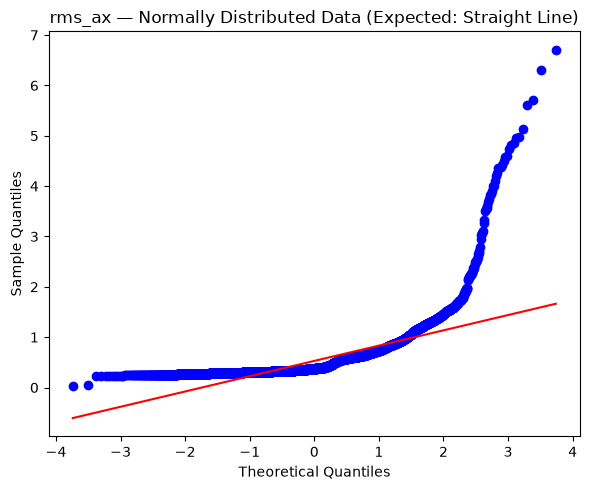

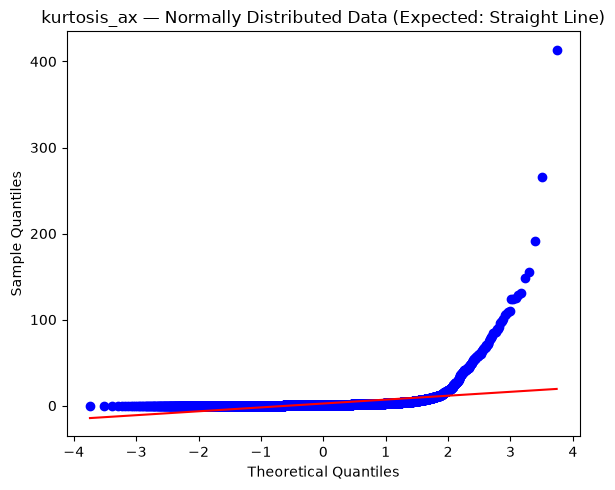

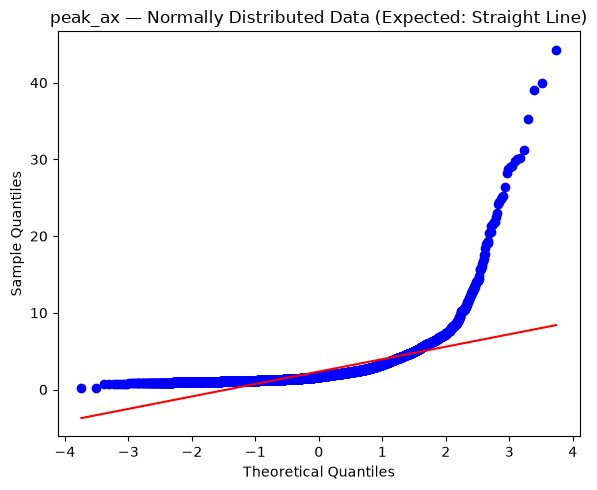

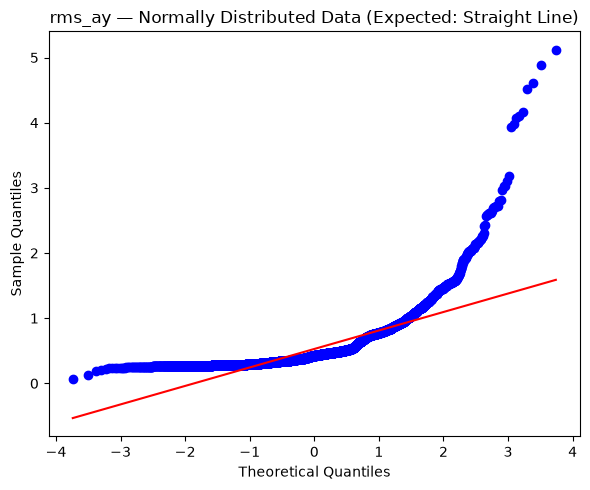

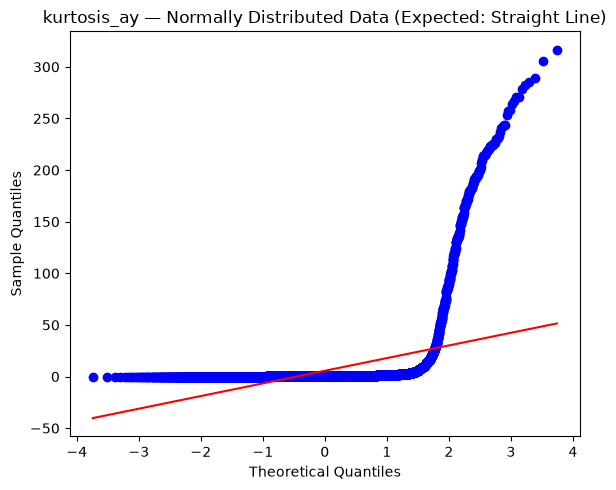

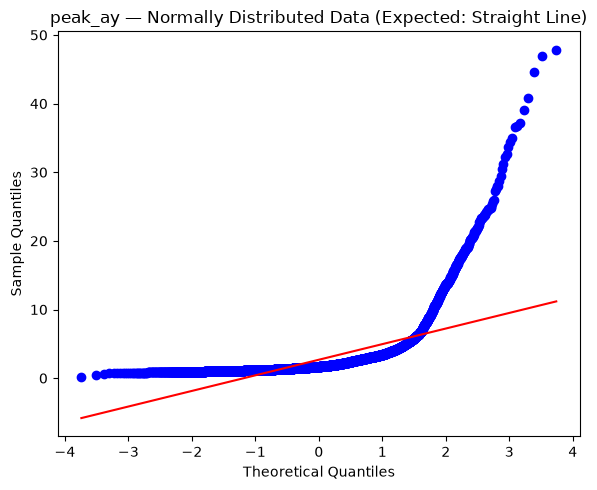

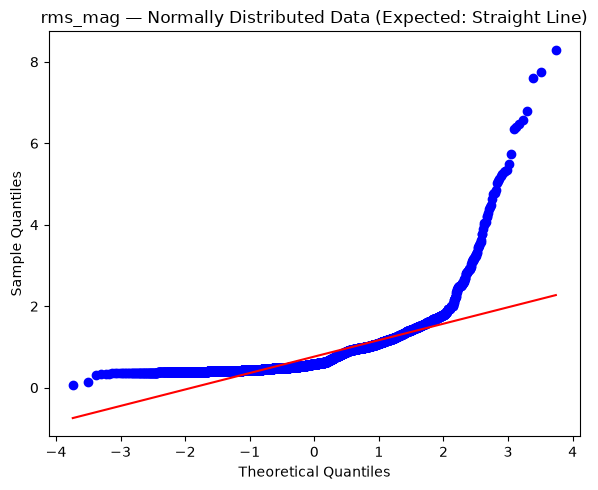

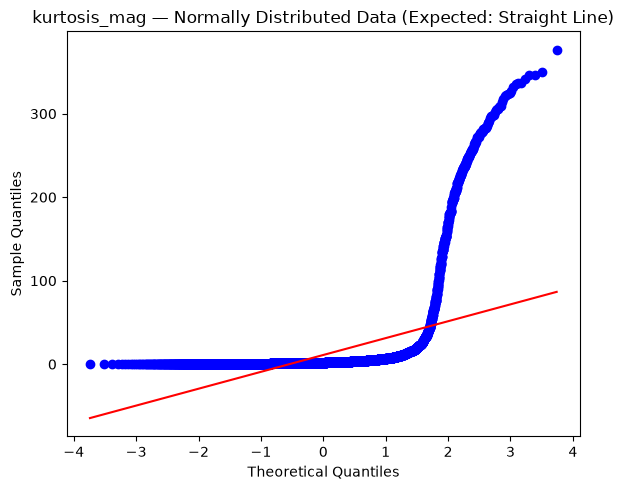

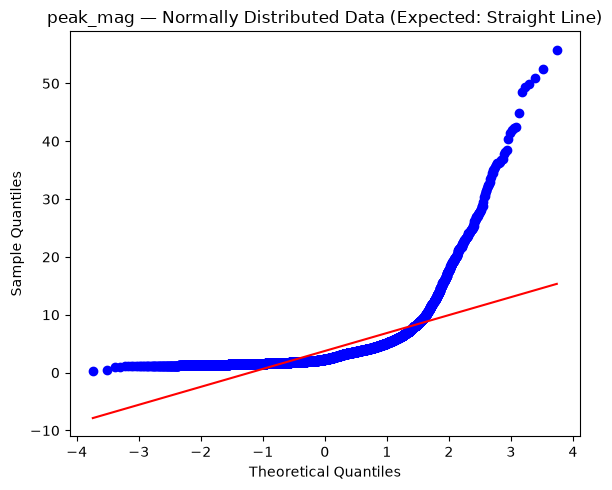

In [10]:
for feature in key_features:
    plt.figure(figsize=(6, 5))
    q_q_plots(filtered_features_df, feature)

In [11]:
#detection of premature deterioration/healty/degraded partial of machines

# Using Unsupervised HI method

    # Unsupervised Health Index (HI) via PCA + Mahalanobis Distance
    
    # Objective: Without using any labels (i.e. without manually classifying as ‘healthy’ or ‘faulty’),
    # to reduce the extent to which each step 
    # ‘deviates’ from that bearing’s OWN early/healthy period to a single number (health_index).
    #
    # 1. PCA: Reduces 30 correlated features (RMS, kurtosis, crest, etc.) to 2 independent 
    #    components — captures the main directions of variation in the data and reduces noise captures the main directions of variation in the data and reduces noise.
    # 2. Mahalanobis: measures how far each step is from the ‘natural dispersion pattern’ of the healthy period 
    #    (unlike simple Euclidean distance, 
    #    it takes into account the correlation between features).
    #
    # Result: when the health_index is low, the step is close to the baseline (likely healthy);
    # as it rises, the bearing’s behaviour drifts away from the healthy period (deterioration).


    # Amaç: Hiçbir etiket kullanmadan (sağlıklı/bozuk diye elle işaretlemeden),
    # her step'in o bearing'in KENDİ erken/sağlıklı döneminden ne kadar 
    # "saptığını" tek bir sayıya (health_index) indirgemek.
    #
    # 1. PCA: 30 korelasyonlu feature'ı (RMS, kurtosis, crest vb.) 2 bağımsız 
    #    bileşene indirger verinin ana varyasyon yönlerini yakalar, gürültüyü azaltır.
    # 2. Mahalanobis: Her step'in, sağlıklı dönemin "doğal saçılma şekline" göre 
    #    ne kadar uzakta olduğunu ölçer (basit Euclidean'dan farklı olarak, 
    #    feature'lar arası korelasyonu hesaba katar).
    #
    # Sonuç: health_index düşükken step baseline'a yakın (muhtemelen sağlıklı),
    # yükseldikçe bearing'in davranışı sağlıklı dönemden uzaklaşıyor (bozulma).

In [12]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

feature_cols = [col for col in features_train_data.columns if col not in ['bearing_id', 'step']]

def calculate_mahalanobis(data, baseline_data):
    mean_vector = np.mean(baseline_data, axis=0)
    cov_matrix = np.cov(baseline_data, rowvar=False)
    inv_cov_matrix = np.linalg.pinv(cov_matrix)
    diff = data - mean_vector
    # Vectorized 
    return np.sqrt(np.einsum('ij,jk,ik->i', diff, inv_cov_matrix, diff))

def compute_hi_for_bearing(df, bearing_id, feature_cols, baseline_frac=0.10):
    b_data = df[df['bearing_id'] == bearing_id].sort_values('step').reset_index(drop=True)
    X = b_data[feature_cols].values
    baseline_size = max(int(len(X) * baseline_frac), 10)
    X_baseline = X[:baseline_size]

    scaler = StandardScaler().fit(X_baseline)
    X_scaled = scaler.transform(X)
    X_baseline_scaled = scaler.transform(X_baseline)

    pca = PCA(n_components=2).fit(X_baseline_scaled)
    X_pca = pca.transform(X_scaled)
    X_baseline_pca = pca.transform(X_baseline_scaled)

    b_data['health_index'] = calculate_mahalanobis(X_pca, X_baseline_pca)
    return b_data


In [13]:
#HI Health index is created
hi_results = pd.concat([
    compute_hi_for_bearing(features_train_data, bid, feature_cols)
    for bid in features_train_data['bearing_id'].unique()
])

In [14]:
hi_results.head(5)

,bearing_id,step,mean_ax,rms_ax,std_ax,skew_ax,kurtosis_ax,peak_ax,p2p_ax,crest_ax,...,rms_mag,std_mag,skew_mag,kurtosis_mag,peak_mag,p2p_mag,crest_mag,shape_mag,impulse_mag,health_index
0,bearing_1,1,-0.000191,0.538710,0.538815,-0.276842,0.409498,1.767,4.097,3.280058,...,0.683523,0.347684,1.017754,1.377136,2.475439,2.462400,3.621589,1.161408,4.206144,2.158436
1,bearing_1,2,0.003091,0.505577,0.505666,-0.081524,0.196925,1.982,3.797,3.920272,...,0.666278,0.331973,0.978966,1.317366,2.308195,2.300385,3.464310,1.153284,3.995333,1.650694
2,bearing_1,3,-0.007987,0.542441,0.542488,0.091990,0.036907,1.830,3.598,3.373639,...,0.706075,0.347445,0.830954,0.684487,2.203390,2.194335,3.120617,1.148627,3.584426,2.139150
3,bearing_1,4,0.022698,0.515008,0.514608,-0.020372,0.089857,1.600,3.486,3.106749,...,0.699846,0.343360,0.839109,0.694571,2.132642,2.126317,3.047303,1.147544,3.496915,1.939683
4,bearing_1,5,0.002741,0.485601,0.485689,0.014214,-0.040428,1.536,3.241,3.163088,...,0.667113,0.323924,0.803853,0.565678,1.994242,1.979109,2.989363,1.143830,3.419325,1.307326


In [15]:
import ruptures as rpt

def find_hi_changepoint(df, bearing_id, pen=50):  
    b_data = df[df['bearing_id'] == bearing_id].sort_values('step')
    signal = b_data['health_index'].values
    algo = rpt.Pelt(model="rbf").fit(signal)
    breakpoints = algo.predict(pen=pen)
    if len(breakpoints) > 1:
        cutoff_step = b_data['step'].iloc[breakpoints[0] - 1]
    else:
        cutoff_step = None
    return cutoff_step

cutoffs = {bid: find_hi_changepoint(hi_results, bid, pen=50) for bid in hi_results['bearing_id'].unique()}

print(cutoffs)
print("\n")
none_bearings = {k: v for k, v in cutoffs.items() if v is None}
print(none_bearings)

{'bearing_1': None, 'bearing_2': np.int64(210), 'bearing_3': np.int64(155), 'bearing_4': np.int64(490), 'bearing_5': np.int64(450), 'bearing_6': np.int64(1635)}


{'bearing_1': None}


In [ ]:
#implementing HI condition over dataset
#bearing_1 and bearing_5 were different cases because their vibrations could not be classified correctly.

def assign_final_regime_label(df, bearing_id, cutoffs, tail_frac=0.10):
    b_data = df[df['bearing_id'] == bearing_id].sort_values('step')
    n = len(b_data)
    cutoff = cutoffs.get(bearing_id)
    tail_start_step = b_data['step'].iloc[int(n * (1 - tail_frac))]

    if cutoff is None or cutoff >= tail_start_step:
        # PELT güvenilir bir tek nokta bulamadı (ya da bulduğu nokta anlamsız şekilde geç) -> sabit %30 kullan
        healthy_end_step = b_data['step'].iloc[int(n * 0.3)]
    else:
        healthy_end_step = cutoff

    def label_step(s):
        if s < healthy_end_step:
            return 'healthy'
        elif s < tail_start_step:
            return 'transition'
        else:
            return 'critical'

    return b_data['step'].apply(label_step)

hi_results['regime_label'] = pd.concat([
    assign_final_regime_label(hi_results, bid, cutoffs)
    for bid in hi_results['bearing_id'].unique()
])
hi_results[['bearing_id', 'step', 'health_index', 'regime_label']].head(10)
hi_results['regime_label'].value_counts()

regime_label
transition    3688
healthy       3089
critical       757
Name: count, dtype: int64

In [17]:
hi_results_b1 = hi_results[
    (hi_results["bearing_id"] == "bearing_1") & 
    (hi_results["regime_label"].isin(["critical", "transition"]))
]
hi_results_b1.head(5)#control

,bearing_id,step,mean_ax,rms_ax,std_ax,skew_ax,kurtosis_ax,peak_ax,p2p_ax,crest_ax,...,std_mag,skew_mag,kurtosis_mag,peak_mag,p2p_mag,crest_mag,shape_mag,impulse_mag,health_index,regime_label
154,bearing_1,155,-0.053750,0.392795,0.389176,-0.736402,21.571180,4.115,9.018,10.476206,...,0.499989,7.648874,95.510239,8.764124,8.754124,11.427850,1.318620,15.068990,3.941146,transition
155,bearing_1,156,-0.003625,0.380553,0.380610,-0.629892,30.081917,4.082,9.785,10.726485,...,0.637741,8.919135,115.950935,12.503116,12.498644,14.435300,1.477505,21.328226,5.871937,transition
156,bearing_1,157,-0.021129,0.326591,0.325970,-0.201833,2.893425,1.696,4.525,5.193042,...,0.535046,10.949446,181.324997,10.742474,10.730432,13.872945,1.383092,19.187555,4.835959,transition
157,bearing_1,158,-0.051505,0.386222,0.382847,-0.605459,16.946400,3.687,8.554,9.546327,...,0.627271,11.705368,207.635620,14.302092,14.290689,16.650005,1.463411,24.365797,6.055274,transition
158,bearing_1,159,0.044760,0.382489,0.379936,-0.914612,21.159025,2.689,8.293,7.030259,...,0.706353,14.005684,261.360596,16.530233,16.517427,18.026251,1.567672,28.259254,7.765716,transition


In [18]:
t = hi_results[hi_results['regime_label']== "transition"]
t.head(1)

,bearing_id,step,mean_ax,rms_ax,std_ax,skew_ax,kurtosis_ax,peak_ax,p2p_ax,crest_ax,...,std_mag,skew_mag,kurtosis_mag,peak_mag,p2p_mag,crest_mag,shape_mag,impulse_mag,health_index,regime_label
154,bearing_1,155,-0.05375,0.392795,0.389176,-0.736402,21.57118,4.115,9.018,10.476206,...,0.499989,7.648874,95.510239,8.764124,8.754124,11.42785,1.31862,15.06899,3.941146,transition


In [19]:
# Detection of differentiation between three groups: Kruskal-Wallis
def kruskal_wallis_regime(df, bearing_id, feature):
    b_data = df[df['bearing_id'] == bearing_id]
    groups = [b_data[b_data['regime_label'] == r][feature]
              for r in ['healthy', 'transition', 'critical']
              if (b_data['regime_label'] == r).sum() > 0]
    if len(groups) < 2:
        return None
    stat, p = stats.kruskal(*groups)
    return {'bearing_id': bearing_id, 'feature': feature, 'kruskal_p': float(p),
            'significant': float(p) < 0.05, 'n_groups': len(groups)}

kw_results = pd.DataFrame([
    r for bid in hi_results['bearing_id'].unique() for feature in key_features
    if (r := kruskal_wallis_regime(hi_results, bid, feature)) is not None
])
kw_results

,bearing_id,feature,kruskal_p,significant,n_groups
0,bearing_1,rms_ax,7.318674e-22,True,3
1,bearing_1,kurtosis_ax,6.149044e-13,True,3
2,bearing_1,peak_ax,8.265021e-01,False,3
3,bearing_1,rms_ay,3.031412e-06,True,3
4,bearing_1,kurtosis_ay,2.334343e-04,True,3
5,bearing_1,peak_ay,4.167086e-01,False,3
6,bearing_1,rms_mag,5.949642e-11,True,3
7,bearing_1,kurtosis_mag,9.373064e-05,True,3
8,bearing_1,peak_mag,4.964277e-01,False,3
9,bearing_2,rms_ax,0.000000e+00,True,3


In [20]:
# Mann Whitneyy and levene test are implemented
def compare_healthy_vs_degraded(df: pd.DataFrame, bearing_id, feature):
    """Compares 'healthy' vs 'critical' regimes. 'transition' is intentionally excluded
    from this pairwise test to keep the two compared groups maximally distinct."""
    b_data = df[df['bearing_id'] == bearing_id]

    healthy = b_data[b_data['regime_label'] == 'healthy'][feature]
    degraded = b_data[b_data['regime_label'] == 'critical'][feature]
    

    _, p_mean = stats.mannwhitneyu(healthy, degraded, alternative='two-sided')
    p_mean = float(p_mean)
    _, p_var = stats.levene(healthy, degraded)
    p_var = float(p_var)

    return {
        'bearing_id': bearing_id, 'feature': feature,
        'healthy_median': np.median(healthy), 'degraded_median': np.median(degraded),
        'p_mean_shift': p_mean, 'p_variance_shift': p_var,
        'significant_mean_shift': p_mean < 0.05, 'significant_variance_shift': p_var < 0.05,
    }

In [21]:
hi_results.isna().sum()

bearing_id      0
step            0
mean_ax         0
rms_ax          0
std_ax          0
skew_ax         0
kurtosis_ax     0
peak_ax         0
p2p_ax          0
crest_ax        0
shape_ax        0
impulse_ax      0
mean_ay         0
rms_ay          0
std_ay          0
skew_ay         0
kurtosis_ay     0
peak_ay         0
p2p_ay          0
crest_ay        0
shape_ay        0
impulse_ay      0
mean_mag        0
rms_mag         0
std_mag         0
skew_mag        0
kurtosis_mag    0
peak_mag        0
p2p_mag         0
crest_mag       0
shape_mag       0
impulse_mag     0
health_index    0
regime_label    0
dtype: int64

In [22]:
valid_bearings = [b for b in hi_results['bearing_id'].unique()]

rows = [
    compare_healthy_vs_degraded(hi_results, bid, feature)
    for bid in valid_bearings
    for feature in key_features
]
print(f"Included in the statistical test: {valid_bearings}")
print("All 6 bearings now use a unified 3-regime scheme (healthy/transition/critical). "
      "bearing_1 and bearing_5 use a fixed 30% healthy boundary since PELT found no reliable "
      "single changepoint for them; the others use their PELT-detected cutoff.")

results = pd.DataFrame(rows)

Included in the statistical test: ['bearing_1', 'bearing_2', 'bearing_3', 'bearing_4', 'bearing_5', 'bearing_6']
All 6 bearings now use a unified 3-regime scheme (healthy/transition/critical). bearing_1 and bearing_5 use a fixed 30% healthy boundary since PELT found no reliable single changepoint for them; the others use their PELT-detected cutoff.


In [23]:
print("--- Healthy vs. Degraded Period Comparison (Mann-Whitney U + Levene) ---\n")
for _, row in results.iterrows():
    print(f"[{row['bearing_id']} | {row['feature']}]")
    print(f"  Healthy median: {row['healthy_median']:.3f}  |  Degraded median: {row['degraded_median']:.3f}")

    if row['significant_mean_shift']:
        print(f"  Mann-Whitney p = {row['p_mean_shift']:.2e} -> Significant shift: "
              f"this feature's distribution genuinely changes as the bearing degrades.")
    else:
        print(f"  Mann-Whitney p = {row['p_mean_shift']:.2e} -> No significant shift: "
              f"this feature does not reliably distinguish healthy from degrading here.")

    if row['significant_variance_shift']:
        print(f"  Levene p = {row['p_variance_shift']:.2e} -> Spread also changes significantly "
              f"(signal becomes noisier/more erratic as it degrades).")
    else:
        print(f"  Levene p = {row['p_variance_shift']:.2e} -> Spread stays statistically stable.")
    print("-" * 70)

summary = results.groupby('bearing_id').agg(
    n_significant_mean=('significant_mean_shift', 'sum'),
    n_significant_variance=('significant_variance_shift', 'sum'),
    total_features=('feature', 'count'),
).reset_index()

print("\n--- Per-Bearing Summary: how many features show a real degradation signal? ---")
print(summary.to_string(index=False))

--- Healthy vs. Degraded Period Comparison (Mann-Whitney U + Levene) ---

[bearing_1 | rms_ax]
  Healthy median: 0.348  |  Degraded median: 0.305
  Mann-Whitney p = 4.80e-11 -> Significant shift: this feature's distribution genuinely changes as the bearing degrades.
  Levene p = 6.68e-01 -> Spread stays statistically stable.
----------------------------------------------------------------------
[bearing_1 | kurtosis_ax]
  Healthy median: 0.222  |  Degraded median: 0.952
  Mann-Whitney p = 1.34e-08 -> Significant shift: this feature's distribution genuinely changes as the bearing degrades.
  Levene p = 1.22e-03 -> Spread also changes significantly (signal becomes noisier/more erratic as it degrades).
----------------------------------------------------------------------
[bearing_1 | peak_ax]
  Healthy median: 1.407  |  Degraded median: 1.338
  Mann-Whitney p = 8.89e-01 -> No significant shift: this feature does not reliably distinguish healthy from degrading here.
  Levene p = 1.78e-01 

In [ ]:
# Pairwise post-hoc comparisons with Bonferroni correction (which specific pair differs?)
from itertools import combinations

def pairwise_bonferroni(df, bearing_id, feature, n_total_comparisons):
    b_data = df[df['bearing_id'] == bearing_id]
    regimes = [r for r in ['healthy', 'transition', 'critical']
               if (b_data['regime_label'] == r).sum() > 5]
    pairs = list(combinations(regimes, 2))

    results = []
    for r1, r2 in pairs:
        g1 = b_data[b_data['regime_label'] == r1][feature]
        g2 = b_data[b_data['regime_label'] == r2][feature]
        _, p = stats.mannwhitneyu(g1, g2, alternative='two-sided')
        p_adjusted = min(p * n_total_comparisons, 1.0)
        results.append({
            'bearing_id': bearing_id, 'feature': feature,
            'pair': f'{r1} vs {r2}', 'p_raw': float(p),
            'p_bonferroni': float(p_adjusted),
            'significant': p_adjusted < 0.05,
        })
    return results

n_bearings = hi_results['bearing_id'].nunique()
n_total_comparisons = n_bearings * len(key_features) * 3  # 3 likely pairs: healthy-transition, transition-critical, healthy-critical

pairwise_rows = []
for bid in hi_results['bearing_id'].unique():
    for feature in key_features:
        pairwise_rows.extend(pairwise_bonferroni(hi_results, bid, feature, n_total_comparisons))

pairwise_results = pd.DataFrame(pairwise_rows)
pairwise_results

,bearing_id,feature,pair,p_raw,p_bonferroni,significant
0,bearing_1,rms_ax,healthy vs transition,3.457825e-20,5.601677e-18,True
1,bearing_1,rms_ax,healthy vs critical,4.797605e-11,7.772120e-09,True
2,bearing_1,rms_ax,transition vs critical,1.390447e-02,1.000000e+00,False
3,bearing_1,kurtosis_ax,healthy vs transition,1.835091e-11,2.972847e-09,True
4,bearing_1,kurtosis_ax,healthy vs critical,1.338100e-08,2.167722e-06,True
...,...,...,...,...,...,...
157,bearing_6,kurtosis_mag,healthy vs critical,0.000000e+00,0.000000e+00,True
158,bearing_6,kurtosis_mag,transition vs critical,5.027645e-27,8.144785e-25,True
159,bearing_6,peak_mag,healthy vs transition,0.000000e+00,0.000000e+00,True
160,bearing_6,peak_mag,healthy vs critical,0.000000e+00,0.000000e+00,True


In [25]:
pairwise_results_f = pairwise_results["significant"] == False

In [26]:
pairwise_results_f.sum()

np.int64(38)

In [27]:

breakdown = pairwise_results.groupby('pair').agg(
    n_significant=('significant', 'sum'),
    n_total=('significant', 'count')
)
breakdown['pct_significant'] = (breakdown['n_significant'] / breakdown['n_total'] * 100).round(1)
breakdown

,n_significant,n_total,pct_significant
pair,,,
healthy vs critical,46,54,85.2
healthy vs transition,46,54,85.2
transition vs critical,32,54,59.3


In [ ]:
# 1. First add columns
def add_rul(df, bearing_id):
    b_data = df[df['bearing_id'] == bearing_id].sort_values('step').copy()
    max_step = b_data['step'].max()
    b_data['RUL'] = max_step - b_data['step']
    b_data['RUL_pct'] = (max_step - b_data['step']) / max_step * 100
    return b_data

hi_results = pd.concat([add_rul(hi_results, bid) for bid in hi_results['bearing_id'].unique()])
hi_results[['bearing_id', 'step', 'RUL', 'RUL_pct']].head()

,bearing_id,step,RUL,RUL_pct
0,bearing_1,1,514,99.805825
1,bearing_1,2,513,99.611650
2,bearing_1,3,512,99.417476
3,bearing_1,4,511,99.223301
4,bearing_1,5,510,99.029126


In [29]:

# ── Trend Feature Engineering ────────────────────────────────────────────────
# Rolling OLS slope captures degradation RATE rather than absolute level,
# making features scale-invariant across bearings and naturally monotonic.
# Selected features are those with statistically significant degradation signal
# (Mann-Whitney p < 0.05, Bonferroni-corrected) across all 6 bearings.

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import r2_score, mean_absolute_error

TREND_WINDOW = 20
TREND_FEATURES = [
    "rms_ax", "kurtosis_ax", "rms_ay", "kurtosis_ay",
    "rms_mag", "kurtosis_mag", "peak_ax", "peak_ay", "peak_mag",
]


def compute_rolling_slopes(df: pd.DataFrame, feature_list: list, window: int) -> pd.DataFrame:
    """Returns df with an additional `{feat}_slope` column per feature.
    Slope = OLS gradient of the feature over the last `window` steps, computed per bearing."""
    x_base = np.arange(window)
    bearing_frames = []
    for bid in df["bearing_id"].unique():
        b = df[df["bearing_id"] == bid].sort_values("step").copy().reset_index(drop=True)
        for feat in feature_list:
            vals = b[feat].values.astype(float)
            slopes = np.empty(len(vals))
            for i in range(len(vals)):
                if i < window - 1:
                    x_w = np.arange(i + 1)
                    slopes[i] = np.polyfit(x_w, vals[: i + 1], 1)[0] if i > 0 else 0.0
                else:
                    slopes[i] = np.polyfit(x_base, vals[i - window + 1 : i + 1], 1)[0]
            b[f"{feat}_slope"] = slopes
        bearing_frames.append(b)
    return pd.concat(bearing_frames, ignore_index=True)


df_model = compute_rolling_slopes(hi_results, TREND_FEATURES, TREND_WINDOW)

slope_cols = [f"{f}_slope" for f in TREND_FEATURES]
print(f"Trend features added ({len(slope_cols)}): {slope_cols}")
print(f"Dataset shape after trend engineering: {df_model.shape}")


Trend features added (9): ['rms_ax_slope', 'kurtosis_ax_slope', 'rms_ay_slope', 'kurtosis_ay_slope', 'rms_mag_slope', 'kurtosis_mag_slope', 'peak_ax_slope', 'peak_ay_slope', 'peak_mag_slope']
Dataset shape after trend engineering: (7534, 45)


In [ ]:

# ── RUL Model: Leave-One-Bearing-Out Evaluation ──────────────────────────────
# Feature set: 30 time-domain features + 9 rolling slopes = 39 total.
# health_index is excluded: it is a per-bearing degradation proxy used only
# for regime labelling (PELT), not as a model input.
# CV protocol: true LeaveOneGroupOut — 6 folds, each holding out 1 bearing.

MODEL_FEATURES = [
    c for c in df_model.columns
    if c not in {"bearing_id", "step", "health_index", "regime_label", "RUL", "RUL_pct"}
]
TARGET = "RUL_pct"

print(f"Model features: {len(MODEL_FEATURES)}  "
      f"(30 time-domain + {len(slope_cols)} slope)")


def evaluate_logo(df: pd.DataFrame, feature_cols: list, target_col: str) -> pd.DataFrame:
    """Leave-One-Bearing-Out CV with RandomForest. Returns per-bearing R² and MAE."""
    X = df[feature_cols].values
    y = df[target_col].values
    groups = df["bearing_id"].values

    records = []
    for train_idx, val_idx in LeaveOneGroupOut().split(X, y, groups):
        test_bearing = df.iloc[val_idx]["bearing_id"].iloc[0]
        model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
        model.fit(X[train_idx], y[train_idx])
        preds = model.predict(X[val_idx])
        records.append({
            "bearing": test_bearing,
            "n_test":  len(val_idx),
            "R²":round(r2_score(y[val_idx], preds), 3),
            "MAE":round(mean_absolute_error(y[val_idx], preds), 2),
        })

    results = pd.DataFrame(records).set_index("bearing")
    results.loc["MEAN"] = results.mean().round(3)
    return results

logo_results = evaluate_logo(df_model, MODEL_FEATURES, TARGET)

print("\nLeave-One-Bearing-Out CV Results (target: RUL_pct)")
print("=" * 42)
print(logo_results.to_string())


Model features: 39  (30 time-domain + 9 slope)

Leave-One-Bearing-Out CV Results (target: RUL_pct)
             n_test     R²     MAE
bearing                           
bearing_1   515.000  0.292  20.610
bearing_2   797.000  0.376  19.770
bearing_3   871.000  0.294  19.070
bearing_4   911.000  0.592  13.890
bearing_5  1637.000 -0.017  23.850
bearing_6  2803.000  0.450  16.710
MEAN       1255.667  0.331  18.983


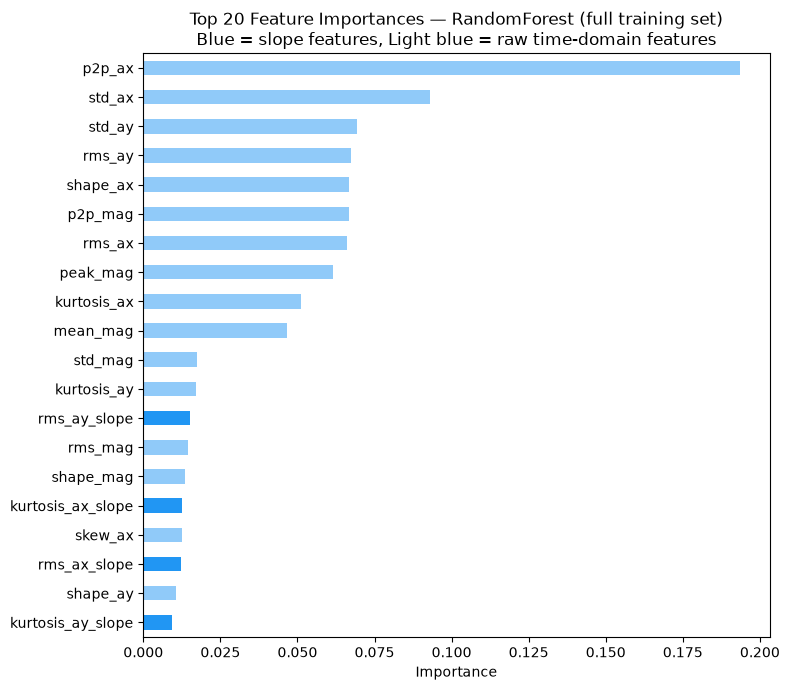

Top 10 features:
p2p_ax         0.1935
std_ax         0.0929
std_ay         0.0693
rms_ay         0.0674
shape_ax       0.0668
p2p_mag        0.0667
rms_ax         0.0660
peak_mag       0.0615
kurtosis_ax    0.0513
mean_mag       0.0467


In [ ]:

# ── Feature Importance ───────────────────────────────────
import matplotlib.pyplot as plt

X_all = df_model[MODEL_FEATURES].values
y_all = df_model[TARGET].values

final_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
final_model.fit(X_all, y_all)

importances = pd.Series(final_model.feature_importances_, index=MODEL_FEATURES).sort_values(ascending=False)
top20 = importances.head(20).sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
colors = ["#2196F3" if "_slope" in f else "#90CAF9" for f in top20.index]
top20.plot(kind="barh", ax=ax, color=colors)
ax.set_title("Top 20 Feature Importances — RandomForest (full training set)\n"
             "Blue = slope features, Light blue = raw time-domain features")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

print("Top 10 features:")
print(importances.head(10).round(4).to_string())


In [34]:
df_model.head(5)

,bearing_id,step,mean_ax,rms_ax,std_ax,skew_ax,kurtosis_ax,peak_ax,p2p_ax,crest_ax,...,RUL_pct,rms_ax_slope,kurtosis_ax_slope,rms_ay_slope,kurtosis_ay_slope,rms_mag_slope,kurtosis_mag_slope,peak_ax_slope,peak_ay_slope,peak_mag_slope
0,bearing_1,1,-0.000191,0.538710,0.538815,-0.276842,0.409498,1.767,4.097,3.280058,...,99.805825,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0000,0.000000
1,bearing_1,2,0.003091,0.505577,0.505666,-0.081524,0.196925,1.982,3.797,3.920272,...,99.611650,-0.033133,-0.212573,0.013249,0.045065,-0.017244,-0.059770,0.2150,0.2430,-0.167244
2,bearing_1,3,-0.007987,0.542441,0.542488,0.091990,0.036907,1.830,3.598,3.373639,...,99.417476,0.001866,-0.186296,0.015644,-0.035291,0.011276,-0.346324,0.0315,0.1230,-0.136024
3,bearing_1,4,0.022698,0.515008,0.514608,-0.020372,0.089857,1.600,3.486,3.106749,...,99.223301,-0.003424,-0.111894,0.017752,-0.013109,0.008877,-0.268057,-0.0653,0.1227,-0.113320
4,bearing_1,5,0.002741,0.485601,0.485689,0.014214,-0.040428,1.536,3.241,3.163088,...,99.029126,-0.009679,-0.100692,0.011333,-0.020945,0.000075,-0.224571,-0.0844,0.1053,-0.113795


In [32]:
df_model.to_parquet(r"C:\Users\elmaz\AIProject\NASA_Project\data\processed_data\model_ready_train.parquet")